In [58]:
import pandas as pd
import os
import pymysql
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [59]:
print("Here is my working directory:", os.getcwd())

Here is my working directory: /Users/andrewhimmelman/Documents/AndrewHimmelman/BAS 479/Case 01


## Initial Things

In [60]:
## Let's get the SQL data inside

with open("credentials.json") as f:
    creds = json.load(f)

con = pymysql.connect(
    host=creds["host"],
    user=creds["username"],
    password=creds["password"],
    database="aspannba_bas479"
)

carbo_transactions = pd.read_sql(
    "SELECT * FROM carbo_transactions;",
    con
)

print(carbo_transactions)

# Comment out the close for now but we will close later after we are done

# con.close()


/var/folders/vk/lswj183x58bbxh5t1j_7qqpc0000gn/T/ipykernel_14308/1428702210.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  carbo_transactions = pd.read_sql(


               upc  dollar_sales  units  time_of_transaction  geography  week  \
0       9999985031          1.58      2                    9          1    43   
1       9999985058          1.58      2                    9          1    43   
2       3620000445          3.22      2                  106          1    43   
3       9999985006          1.39      1                  106          1    43   
4       2920000214          1.09      1                   51          1    43   
...            ...           ...    ...                  ...        ...   ...   
324355  4420979347          4.49      1                 1859          2    72   
324356  7107201136          3.19      1                 1859          2    72   
324357  9999981816          4.29      1                 2321          1    72   
324358  3000005070          1.99      1                 2312          1    72   
324359  7130000027          1.98      2                 2339          1    72   

       household  store   b

In [61]:

## Also we need to make sure that we load in the other files

carbo_product_lookup = pd.read_csv("Data/carbo_product_lookup.csv")

carbo_promotion_lookup = pd.read_json("Data/carbo_promotion_lookup.json")

print("Everything seems to be loaded in correctly.",
      "Carbo_Product Shape:", carbo_product_lookup.shape,
      "Carbo_Promotion Shape:", carbo_promotion_lookup.shape)

Everything seems to be loaded in correctly. Carbo_Product Shape: (670, 5) Carbo_Promotion Shape: (17263, 6)


## Case 1 Work Prompt Choosing

### Prompt 1: Which stores have the highest total sales?

In [62]:
prompt_1_data = pd.read_sql(
    "SELECT "
    "store, "
    "SUM(dollar_sales) AS Total_Sales "
    "FROM carbo_transactions "
    "GROUP BY store "
    "ORDER BY Total_Sales DESC;",
    con
    
)

print(prompt_1_data)
print(prompt_1_data.head(n = 2))

    store   Total_Sales
0     359  17440.060080
1     270  17275.430080
2     322  17253.160057
3     316  15841.150069
4     371  15321.260054
5     326  15160.720058
6     375  15132.980080
7      71  15067.590087
8     308  14210.250044
9     259  13177.480047
10    378  13018.470048
11    368  12977.430070
12    264  12868.710057
13    307  12674.670038
14    196  12542.470066
15    373  12466.460042
16    280  12196.520068
17    309  12171.320058
18    357  11369.530061
19    235  11351.050053
20    186  11260.540073
21    249  10965.330047
22    341  10846.200057
23     17  10732.830069
24    321  10719.440058
25     35  10469.070069
26    162  10429.090071
27    285  10401.800047
28    240  10387.910036
29     33  10374.060041
30     54  10339.290065
31    353  10325.320025
32    324  10308.820054
33    356  10258.910045
34    184  10092.890067
35    366  10077.430059
36     16  10018.590071
37    241   9877.820039
38    215   9874.480038
39    227   9808.420042
40    172   9763

/var/folders/vk/lswj183x58bbxh5t1j_7qqpc0000gn/T/ipykernel_14308/330019795.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  prompt_1_data = pd.read_sql(


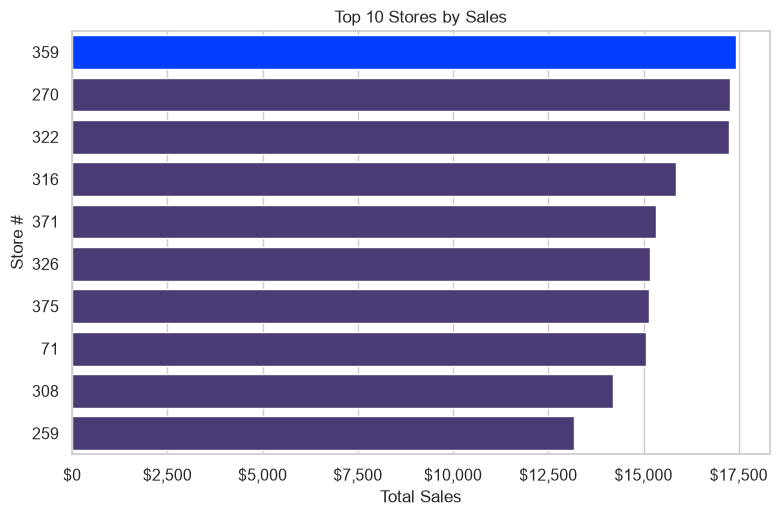

In [63]:
top_10_stores = prompt_1_data.head(n = 10).sort_values("Total_Sales", ascending = False)

top_10_stores["store"] = top_10_stores["store"].astype(str)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

sns.set_palette("viridis")

fig, ax = plt.subplots(figsize=(9, 5.5))

bar_chart = sns.barplot(
    data = top_10_stores,
    x = "Total_Sales",
    y = "store",
    ax = ax
)

ax.patches[0].set_facecolor(
    sns.color_palette("bright")[0]
)

ax.set(
    title = "Top 10 Stores by Sales",
    xlabel = "Total Sales",
    ylabel = "Store #"
)

ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)

plt.show()

### Prompt 2: Are coupon transactions larger than non-coupon transactions?

In [64]:
prompt_2_data = pd.read_sql(
    "SELECT "
    "coupon, "
    "AVG(dollar_sales) as Avg_Sales "
    "FROM carbo_transactions "
    "GROUP BY coupon ", 
    con
)

print(prompt_2_data)

   coupon  Avg_Sales
0       0   1.801619
1       1   1.654341


/var/folders/vk/lswj183x58bbxh5t1j_7qqpc0000gn/T/ipykernel_14308/3860299390.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  prompt_2_data = pd.read_sql(


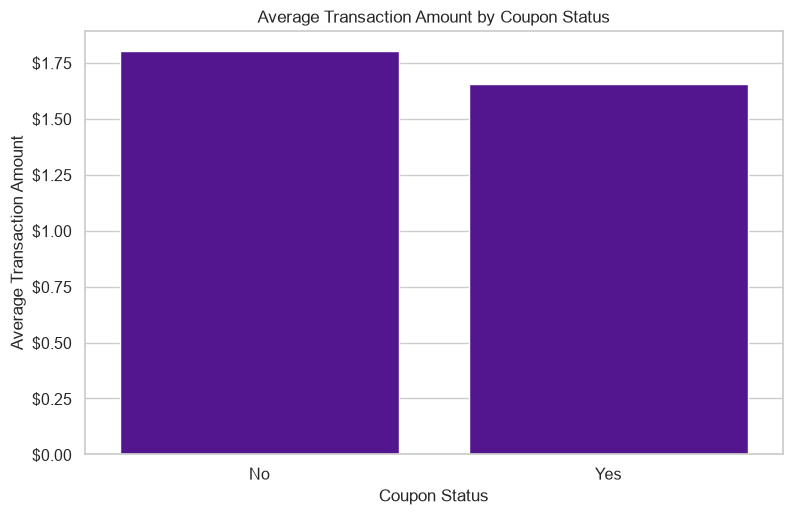

In [70]:
chart_2_df = prompt_2_data

chart_2_df["Coupon_Status"] = chart_2_df["coupon"].map({
    0: "No",
    1: "Yes"
})

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

sns.set_palette("plasma")

fig, ax = plt.subplots(figsize=(9, 5.5))

bar_chart_2 = sns.barplot(
    data = chart_2_df,
    x = "Coupon_Status",
    y = "Avg_Sales",
    ax = ax
)

ax.set(
    title = "Average Transaction Amount by Coupon Status",
    xlabel = "Coupon Status",
    ylabel = "Average Transaction Amount"
)

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:.2f}")
)
